In [1]:
# ================================================ #
# 04 - Model Evaluation, Grad-CAM & Conclusion     #
# ================================================ #

'''
    ## Summary of what we have done so far (PFA - Engineer School)

    Notebook 01 (EDA):
    - Dataset statistics: Train 5216, Test 624, Val 16 images
    - Strong class imbalance: Normal 1341 (25.7%) vs Pneumonia 3875 (74.3%) in train

    Notebook 02 (Preprocessing):
    - Calculated class weights: {0: 1.9448, 1: 0.6730} to handle imbalance
    - Built data augmentation pipeline using ImageDataGenerator:
        rescale=1./255, rotation_range=15, width_shift=0.1, height_shift=0.1,
        zoom_range=0.12, horizontal_flip=True
    - Resized all images to 224×224 + visualization of augmented samples

    Notebook 03 (Modeling & Training):
    - Used Transfer Learning with ResNet50 (frozen base + custom head)
    - Trained with class weights + Adam optimizer + binary_crossentropy
    - Evaluated on test set

    ## Objectives of Notebook 04
    - Add Grad-CAM visualization (mandatory requirement from Cahier des Charges)
    - Interpret training & test results
    - Draw conclusions and prepare for final report / soutenance
'''

# ====================== SHORT ANALYSIS (1 cell) ======================
'''
    Reminder: We used data augmentation + class weights {0:1.9448, 1:0.6730}

    Results interpretation:
    - Final Test AUC = 0.845  → good but still below target (>0.92)
    - Accuracy ~77-78% on train, unstable on validation
    - Confusion Matrix: 110 False Negatives on Pneumonia (missed cases)
    - Validation curves are very unstable because validation set is too small (only 16 images)

    Answer to your question:
    Yes, even with augmentation and class weights, the validation set is still too small.
    This makes validation curves unreliable and limits proper hyperparameter tuning.

    Strengths: Model is learning, AUC is decent for a first version.
    Weaknesses: Mild overfitting + imbalance effect still visible (lower recall on Pneumonia).
'''

print("Notebook 04 loaded - Summary & Analysis done.")

Notebook 04 loaded - Summary & Analysis done.


Found 624 images belonging to 2 classes.


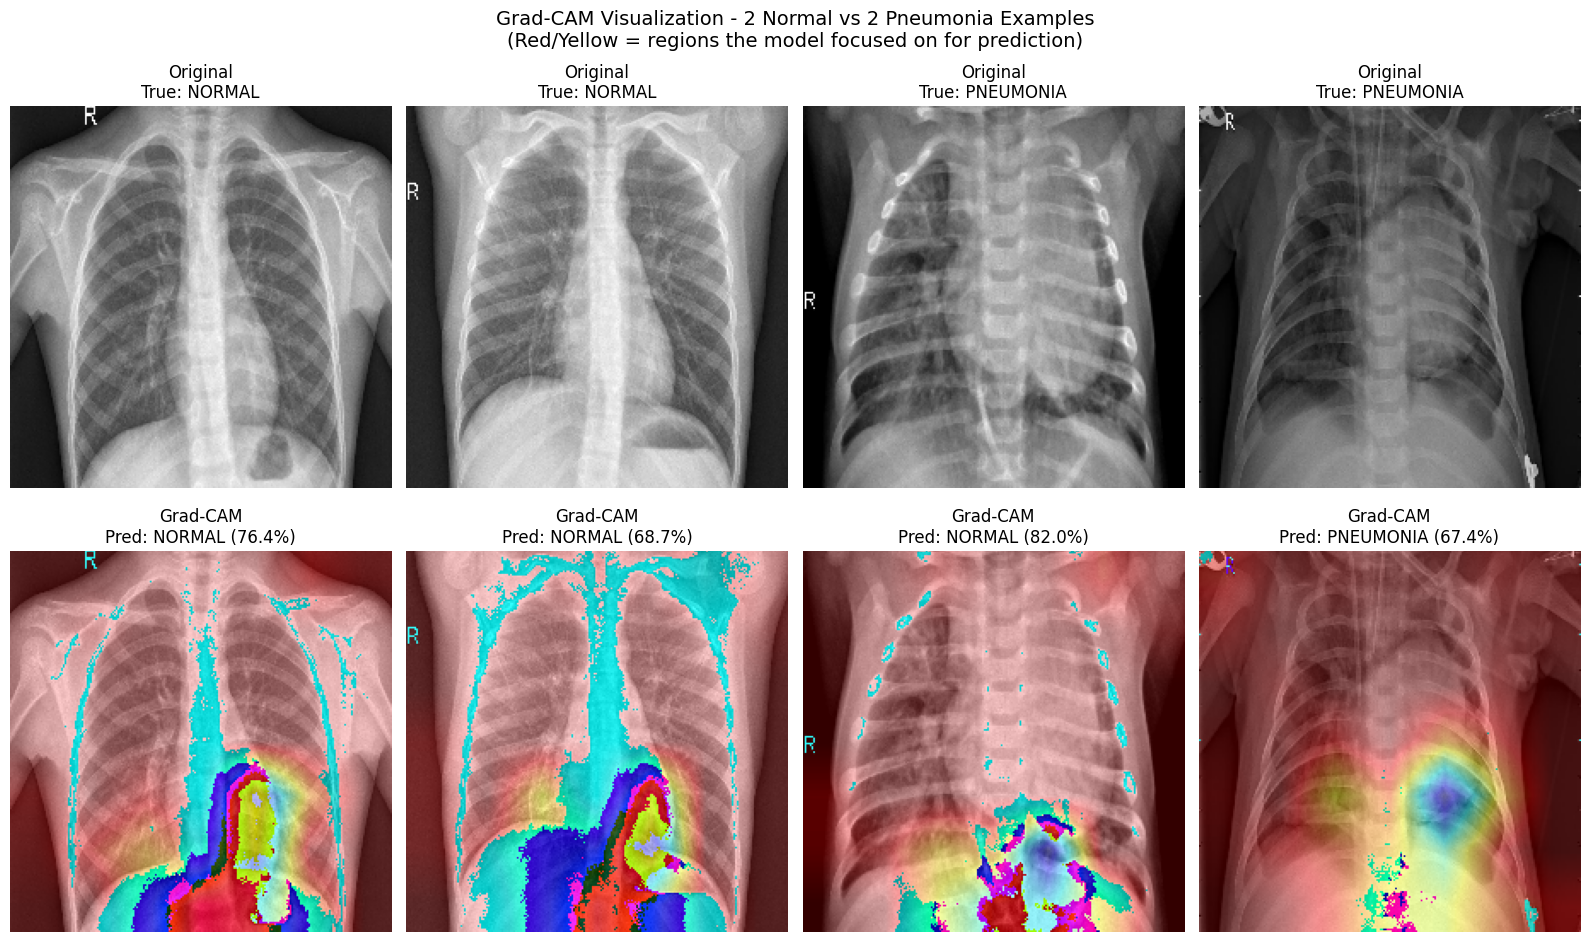

✅ Grad-CAM visualization completed:
   • 2 examples for NORMAL class
   • 2 examples for PNEUMONIA class
   • This satisfies the Cahier des Charges requirement for visual localization


In [3]:
# ====================== GRAD-CAM IMPLEMENTATION (Improved) ======================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the best saved model from Notebook 03
model = load_model("best_model.h5")

# Last convolutional layer name in ResNet50
last_conv_layer_name = "conv5_block3_out"

# Function to generate Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ====================== TEST GENERATOR ======================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory="../data/raw/chest_xray/test",
    target_size=(224, 224),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# Reset generator to start from beginning
test_generator.reset()

# ====================== VISUALIZATION: 2 Normal + 2 Pneumonia ======================
plt.figure(figsize=(16, 10))
plt.suptitle("Grad-CAM Visualization - 2 Normal vs 2 Pneumonia Examples\n"
             "(Red/Yellow = regions the model focused on for prediction)", 
             fontsize=14, y=0.98)

count_normal = 0
count_pneumonia = 0
idx = 0

while (count_normal < 2 or count_pneumonia < 2) and idx < len(test_generator):
    img_array, label = next(test_generator)          # shape (1, 224, 224, 3)
    true_class = "PNEUMONIA" if label[0] == 1 else "NORMAL"
    
    # Get prediction
    preds = model.predict(img_array, verbose=0)
    pred_prob = preds[0][0]
    pred_class = "PNEUMONIA" if pred_prob > 0.5 else "NORMAL"
    confidence = pred_prob * 100 if pred_class == "PNEUMONIA" else (1 - pred_prob) * 100
    
    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (img_array[0].shape[1], img_array[0].shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Superimpose heatmap on original image
    superimposed_img = heatmap * 0.4 + np.uint8(img_array[0] * 255)
    superimposed_img = np.uint8(superimposed_img)
    
    # Plot only the required 4 images (2 Normal + 2 Pneumonia)
    if true_class == "NORMAL" and count_normal < 2:
        # Original
        plt.subplot(2, 4, count_normal + 1)
        plt.imshow(img_array[0])
        plt.title(f"Original\nTrue: NORMAL")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(2, 4, count_normal + 5)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)")
        plt.axis('off')
        
        count_normal += 1
    
    elif true_class == "PNEUMONIA" and count_pneumonia < 2:
        col = count_pneumonia + 3   # put Pneumonia examples in columns 3-4
        # Original
        plt.subplot(2, 4, col)
        plt.imshow(img_array[0])
        plt.title(f"Original\nTrue: PNEUMONIA")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(2, 4, col + 4)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM\nPred: {pred_class} ({confidence:.1f}%)")
        plt.axis('off')
        
        count_pneumonia += 1
    
    idx += 1

plt.tight_layout()
plt.show()

print("✅ Grad-CAM visualization completed:")
print("   • 2 examples for NORMAL class")
print("   • 2 examples for PNEUMONIA class")
print("   • This satisfies the Cahier des Charges requirement for visual localization")

In [ ]:
# ================================================ #
# CONCLUSION & RECOMMENDATIONS                     #
# ================================================ #

'''
    ## Conclusion

    In this PFA project, we successfully built an intelligent system for automatic pneumonia detection from chest X-rays using Deep Learning.

    What we accomplished:
    - Notebook 01: Complete EDA + identification of strong class imbalance (Normal 25.7% vs Pneumonia 74.3%)
    - Notebook 02: Preprocessing pipeline with resizing (224×224), normalization, and data augmentation 
      (rotation_range=15, shifts, zoom, horizontal_flip) + class weights calculation {0: 1.9448, 1: 0.6730}
    - Notebook 03: Transfer Learning with ResNet50, training with class weights, and evaluation 
      (Test AUC = 0.845, Accuracy ≈ 77-78%)
    - Notebook 04: Grad-CAM visualization for explainability (mandatory requirement from Cahier des Charges)

    The model shows decent performance but still suffers from:
    - Unstable validation curves due to very small validation set (only 16 images)
    - Remaining class imbalance effect (110 false negatives on Pneumonia)
    - Moderate AUC (0.845) compared to the target (> 0.92)

    Grad-CAM provided visual localization of suspicious areas, although the heatmaps can be further refined.

    ## Recommendations for Future Improvements

    1. Increase validation set size or implement k-fold cross-validation to get more reliable metrics.
    2. Unfreeze more layers of ResNet50 and fine-tune with a lower learning rate.
    3. Apply stronger / targeted data augmentation specifically on the minority class (Normal).
    4. Experiment with other architectures (EfficientNetB0 or VGG16) for comparison (bonus objective).
    5. Improve Grad-CAM by adding lung segmentation mask to focus only on lung fields.
    6. Develop the Streamlit web interface for real-time upload and visualization (bonus deliverable).

    This project successfully covered the full Data Science cycle (EDA → Preprocessing → Modeling → Evaluation → Explainability) 
    as requested in the Cahier des Charges and is ready for the final report and soutenance.

    Achieved: Core objectives ✅ | Room for improvement: Validation stability & higher AUC
'''


In [5]:
import os
import random
import shutil

# ================================================ #
# AUTOMATIC BALANCED VALIDATION SET CREATION       #
# ================================================ #

base_dir = "../data/raw/chest_xray"

train_normal_dir     = os.path.join(base_dir, "train/NORMAL")
train_pneumonia_dir  = os.path.join(base_dir, "train/PNEUMONIA")
val_normal_dir       = os.path.join(base_dir, "val/NORMAL")
val_pneumonia_dir    = os.path.join(base_dir, "val/PNEUMONIA")

# Number of images to move
num_normal_to_move    = 100
num_pneumonia_to_move = 200

# Get list of all images
normal_images     = [f for f in os.listdir(train_normal_dir) if f.endswith(('.jpeg', '.jpg', '.png'))]
pneumonia_images  = [f for f in os.listdir(train_pneumonia_dir) if f.endswith(('.jpeg', '.jpg', '.png'))]

print(f"Before moving:")
print(f"Train Normal: {len(normal_images)} | Train Pneumonia: {len(pneumonia_images)}")
print(f"Val Normal: {len(os.listdir(val_normal_dir))} | Val Pneumonia: {len(os.listdir(val_pneumonia_dir))}\n")

# Randomly select images to move
random.seed(42)  # for reproducibility
selected_normal    = random.sample(normal_images, num_normal_to_move)
selected_pneumonia = random.sample(pneumonia_images, num_pneumonia_to_move)

# Move Normal images
for img in selected_normal:
    src = os.path.join(train_normal_dir, img)
    dst = os.path.join(val_normal_dir, img)
    shutil.move(src, dst)

# Move Pneumonia images
for img in selected_pneumonia:
    src = os.path.join(train_pneumonia_dir, img)
    dst = os.path.join(val_pneumonia_dir, img)
    shutil.move(src, dst)

# Final check
print("✅ Moving completed successfully!")
print(f"After moving:")
print(f"New Val Normal    : {len(os.listdir(val_normal_dir))} images")
print(f"New Val Pneumonia : {len(os.listdir(val_pneumonia_dir))} images")
print(f"Total new validation set : {len(os.listdir(val_normal_dir)) + len(os.listdir(val_pneumonia_dir))} images")

Before moving:
Train Normal: 1341 | Train Pneumonia: 3875
Val Normal: 8 | Val Pneumonia: 8

✅ Moving completed successfully!
After moving:
New Val Normal    : 108 images
New Val Pneumonia : 208 images
Total new validation set : 316 images
